## NEURAL NETWORKS

In [1]:
import torch
import torch.nn as nn
import dataloader as dl
import torch.optim as SGD
import torch.nn.init as init
import matplotlib.pyplot as plt
import numpy as np

## Creating neural netwrok layers

In [2]:
layer1 = nn.Linear(28*28, 128)
layer2 = nn.Linear(128, 64)
layer3 = nn.Linear(64, 10)

## Initializing weights and biases using he initialization

In [3]:
init.kaiming_uniform_(layer1.weight, nonlinearity='relu')
init.kaiming_uniform_(layer2.weight, nonlinearity='relu')
init.kaiming_uniform_(layer3.weight)

Parameter containing:
tensor([[ 0.1101,  0.2091,  0.2074, -0.2932, -0.2577,  0.0287,  0.2112,  0.0388,
          0.1792,  0.0548, -0.2910,  0.1198, -0.0306,  0.1529, -0.2114, -0.1204,
         -0.0321, -0.1500,  0.1339, -0.1150,  0.0611,  0.0987, -0.2958,  0.1175,
         -0.0954,  0.1941,  0.2357, -0.1219,  0.2763, -0.1461,  0.2362, -0.0840,
          0.2934, -0.0718, -0.0915,  0.1438, -0.2537, -0.0412, -0.1086, -0.1594,
         -0.2703, -0.2764, -0.0196, -0.2252,  0.1825,  0.2169, -0.3043,  0.0065,
          0.1664, -0.1480,  0.1103,  0.2549,  0.0391, -0.0528, -0.1954, -0.1122,
          0.2644, -0.2213, -0.1908, -0.1410, -0.0667,  0.1117, -0.1330,  0.0955],
        [ 0.1616,  0.1308, -0.2746, -0.2604,  0.2581,  0.0655, -0.2038,  0.2647,
          0.0671,  0.1694, -0.2061,  0.0191, -0.1770, -0.1696, -0.2660, -0.2041,
          0.2978,  0.2037,  0.0916, -0.2743, -0.2906, -0.1903, -0.1156, -0.0253,
          0.3013,  0.1472,  0.2729,  0.0411,  0.2013,  0.1512, -0.1320, -0.2903,
     

## Creating the neural network model

In [4]:
neural_network = nn.Sequential(
    layer1,
    nn.ReLU(),
    layer2,
    nn.ReLU(),
    layer3,
)


# Training the model

### Setting up the loss function and optimizer

In [5]:

num_epochs = 20
loss_function = None
optimizer = None
loader= None
train_losses = []
val_losses = []
train_accs = []
val_accs = []
test_acc_list = []

# Mocing the model to Gpu to make it faster
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
neural_network.to(device)


Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

### function to set the HyperParameters

In [6]:
def parameter_setter(learning_rate=.01,num_epochs=20,batch_size=64):
   global loss_function, optimizer, loader
   loss_function = nn.CrossEntropyLoss()
   optimizer = SGD.SGD(neural_network.parameters(), lr=learning_rate)
   loader=dl.build_loader(batch_size)

### function to clear the neural Network

In [7]:
def clear_nn():
  init.kaiming_uniform_(layer1.weight, nonlinearity='relu')
  init.kaiming_uniform_(layer2.weight, nonlinearity='relu')
  init.kaiming_uniform_(layer3.weight)
  neural_network = nn.Sequential(
    layer1,
    nn.ReLU(),
    layer2,
    nn.ReLU(),
    layer3,
)
  global train_losses, val_losses, train_accs, val_accs
  train_losses = []
  val_losses = []
  train_accs = []
  val_accs = []
  test_acc_list = []

In [8]:

parameter_setter()

def train_model():
    clear_nn()
    for epoch in range(num_epochs):
        # TRAINING
        train_loss = 0
        train_correct = 0
        train_total = 0

        for data, target in loader['train_loader_linear']:
            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()
            output = neural_network(data)
            loss = loss_function(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(output, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()

        # VALIDATION
        neural_network.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in loader['val_loader_linear']:
                data = data.to(device)
                target = target.to(device)

                output = neural_network(data)
                loss = loss_function(output, target)

                val_loss += loss.item()
                _, predicted = torch.max(output, 1)
                val_total += target.size(0)
                val_correct += (predicted == target).sum().item()

        # Calculate averages
        train_loss = train_loss / len(loader['train_loader_nn'])
        val_loss = val_loss / len(loader['val_loader_nn'])
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Print progress
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
train_model()


Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.9689 | Train Acc: 73.90%
  Val Loss: 0.5117 | Val Acc: 85.92%
Epoch 2/20
  Train Loss: 0.4284 | Train Acc: 88.03%
  Val Loss: 0.3812 | Val Acc: 89.02%
Epoch 3/20
  Train Loss: 0.3474 | Train Acc: 

## Training and Validation Loss

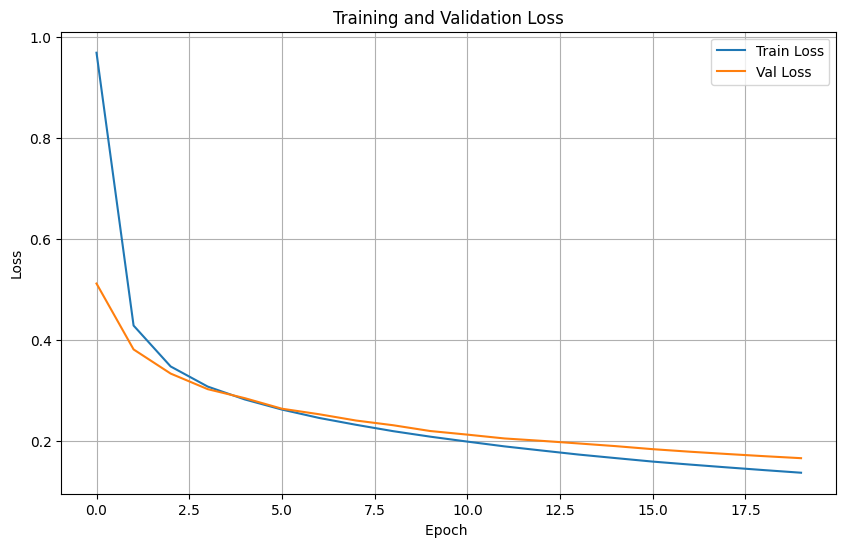

In [15]:
def plot_loss(text):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_loss('')

## Training and Validation Accuracy

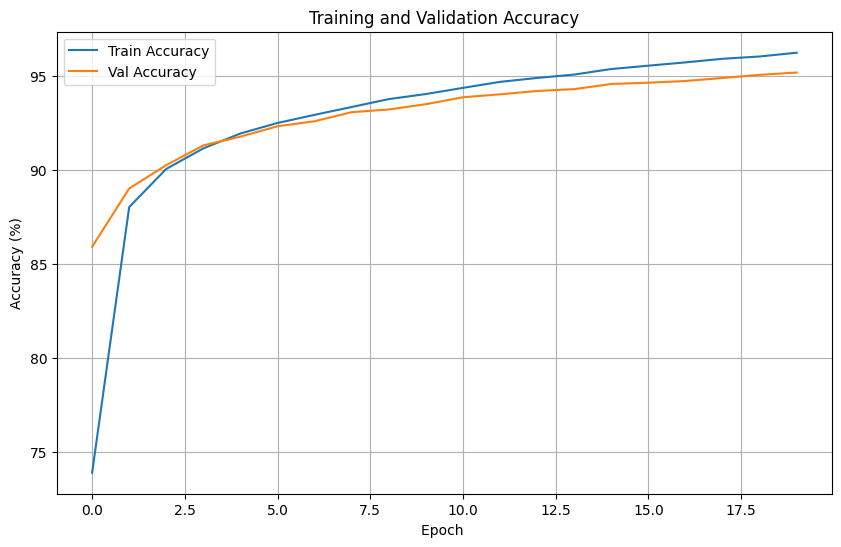

In [18]:

def plot_acc(text):
    plt.figure(figsize=(10, 6))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_acc('')



## Learning Curves with Error Bars

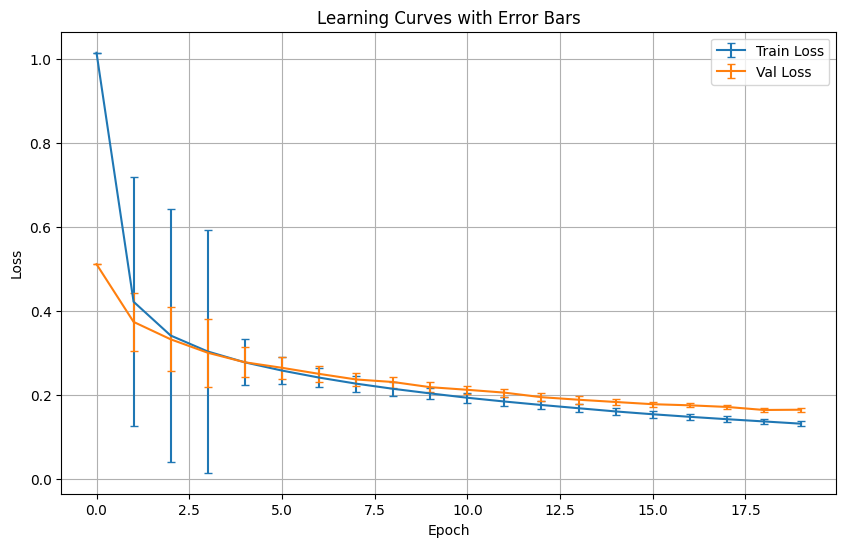

In [ ]:

window = 3
train_std = [np.std(train_losses[max(0,i-window):i+1]) for i in range(len(train_losses))]
val_std = [np.std(val_losses[max(0,i-window):i+1]) for i in range(len(val_losses))]

plt.figure(figsize=(10, 6))
plt.errorbar(range(len(train_losses)), train_losses, yerr=train_std, label='Train Loss', capsize=3)
plt.errorbar(range(len(val_losses)), val_losses, yerr=val_std, label='Val Loss', capsize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves with Error Bars')
plt.legend()
plt.grid(True)
plt.show()


## Convergence Analysis

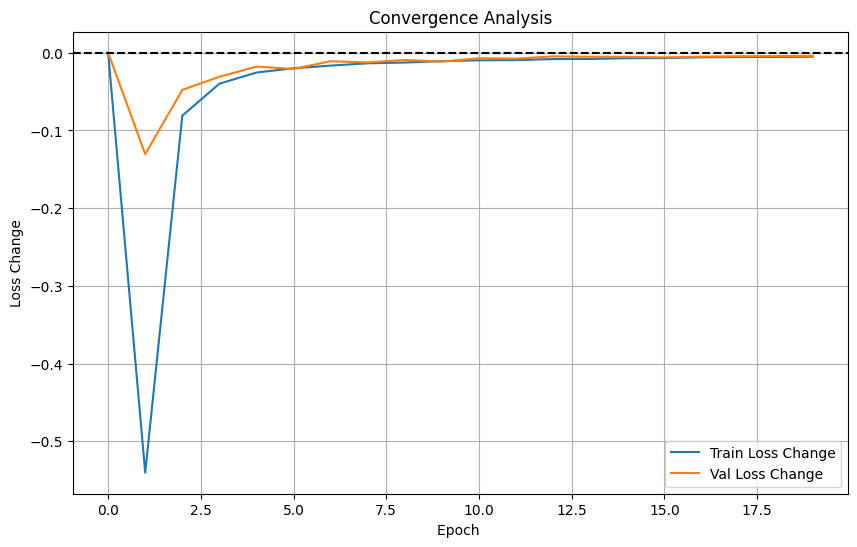

In [17]:

def plot_converge(text):
    train_change = [0] + [train_losses[i] - train_losses[i-1] for i in range(1, len(train_losses))]
    val_change = [0] + [val_losses[i] - val_losses[i-1] for i in range(1, len(val_losses))]

    plt.figure(figsize=(10, 6))
    plt.plot(train_change, label='Train Loss Change')
    plt.plot(val_change, label='Val Loss Change')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel(f"Epoch {text}")
    plt.ylabel('Loss Change')
    plt.title('Convergence Analysis')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_converge('')

## Testing the model

In [24]:


def predict_test():
    for data, target in loader['test_loader_linear']:
        data = data.to(device)
        target = target.to(device)

        output = neural_network(data)
        _, predicted = torch.max(output, 1)

        test_total = target.size(0)
        test_correct = (predicted == target).sum().item()

        test_acc = 100 * test_correct / test_total
        test_acc_list.append(test_acc)

    average_test_acc = sum(test_acc_list) / len(test_acc_list)

    print(f'Average Test Accuracy over all batches: {average_test_acc:.2f}%')
predict_test()

Average Test Accuracy over all batches: 95.21%


# Hyperparameter Analysis

## Learning Rate

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 2.2605 | Train Acc: 22.92%
  Val Loss: 2.0707 | Val Acc: 36.83%
Epoch 2/20
  Train Loss: 1.9130 | Train Acc: 50.84%
  Val Loss: 1.7605 | Val Acc: 60.88%
Epoch 3/20
  Train Loss: 1.6053 | Train Acc: 

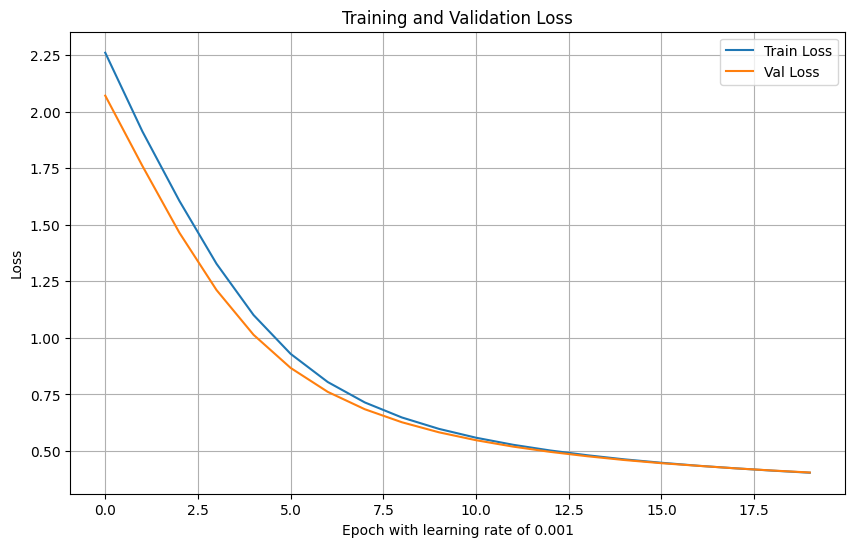

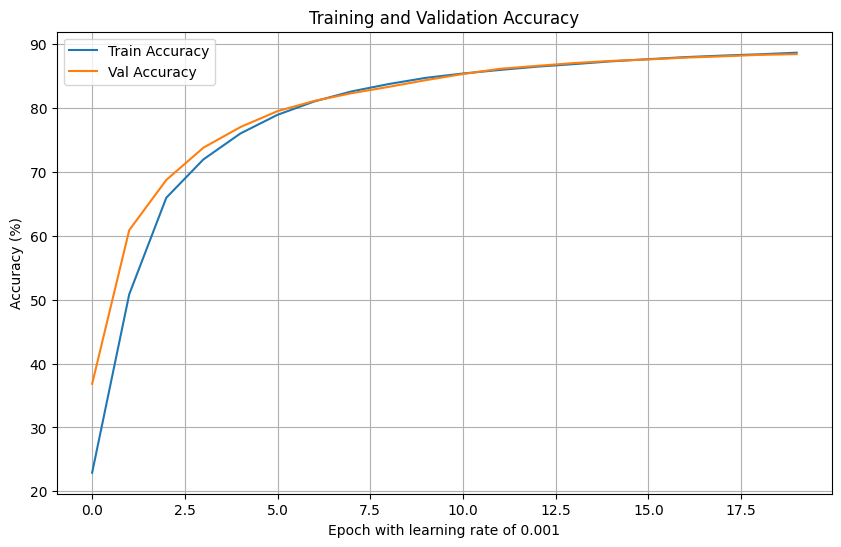

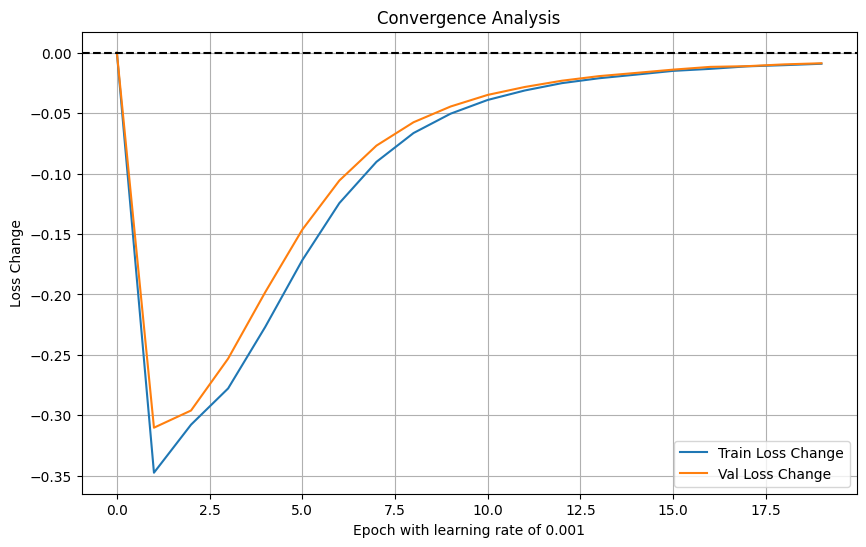

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 1.1430 | Train Acc: 69.74%
  Val Loss: 0.5748 | Val Acc: 84.82%
Epoch 2/20
  Train Loss: 0.4641 | Train Acc: 87.58%
  Val Loss: 0.4013 | Val Acc: 88.97%
Epoch 3/20
  Train Loss: 0.3680 | Train Acc: 

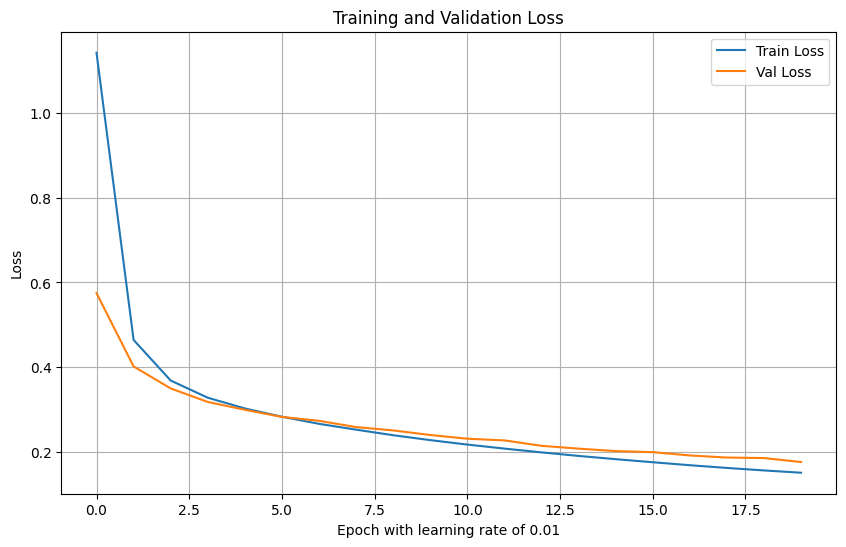

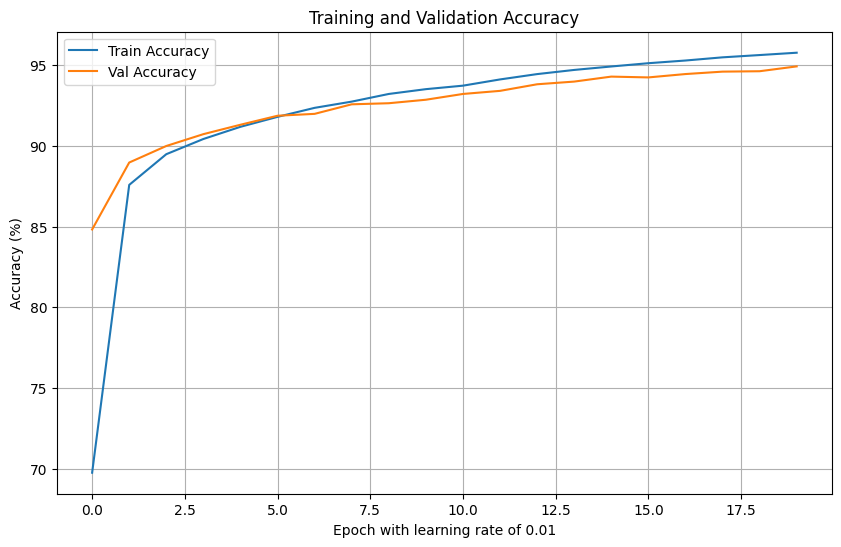

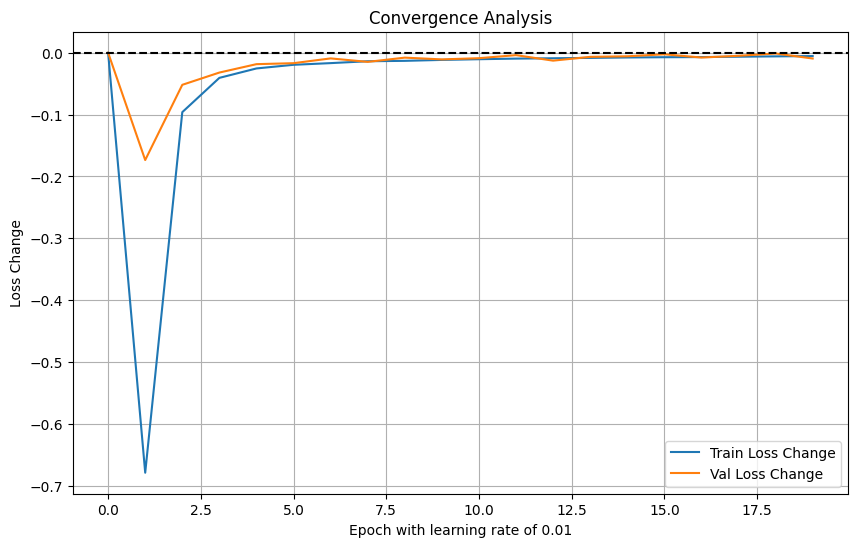

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.4534 | Train Acc: 86.46%
  Val Loss: 0.2382 | Val Acc: 92.98%
Epoch 2/20
  Train Loss: 0.2032 | Train Acc: 93.99%
  Val Loss: 0.2114 | Val Acc: 93.43%
Epoch 3/20
  Train Loss: 0.1475 | Train Acc: 

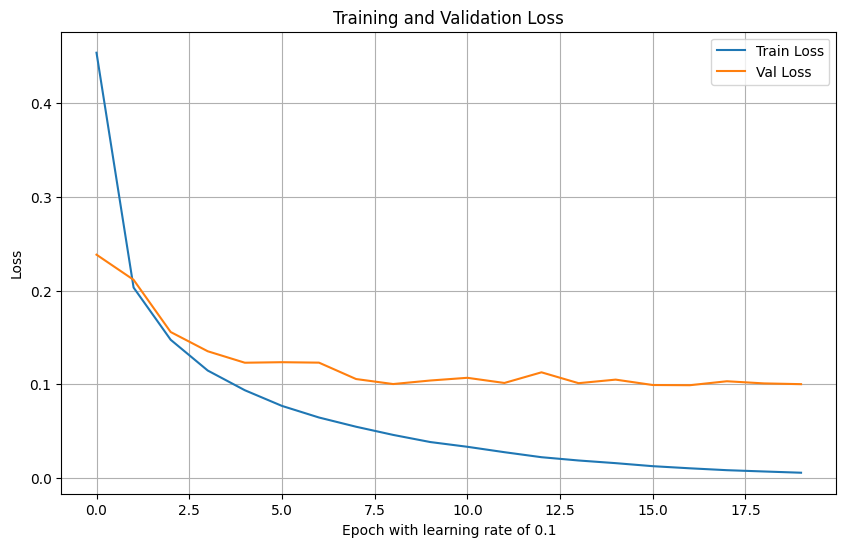

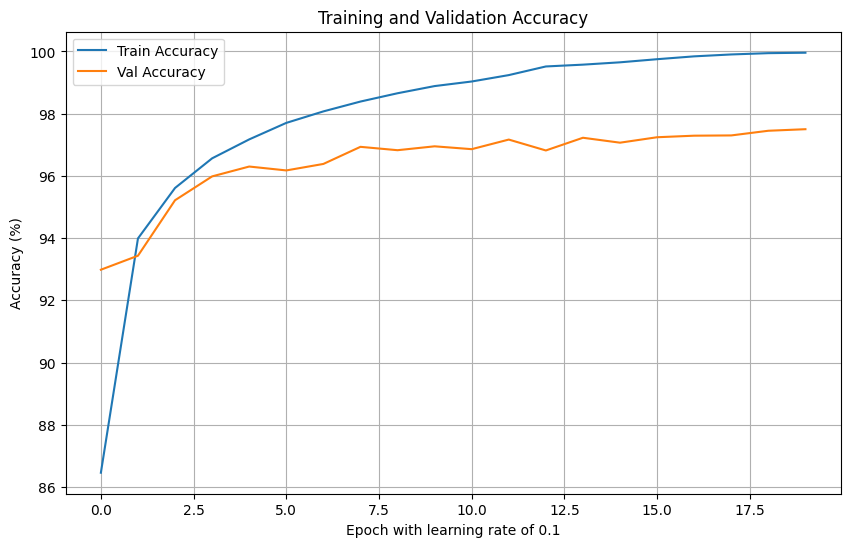

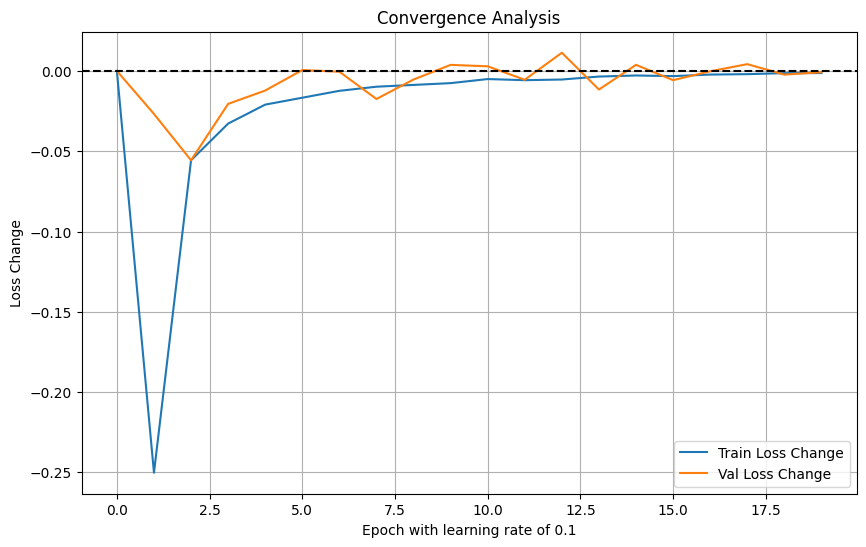

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.7271 | Train Acc: 77.39%
  Val Loss: 0.3173 | Val Acc: 90.81%
Epoch 2/20
  Train Loss: 0.2704 | Train Acc: 92.22%
  Val Loss: 0.6502 | Val Acc: 80.93%
Epoch 3/20
  Train Loss: 0.2156 | Train Acc: 

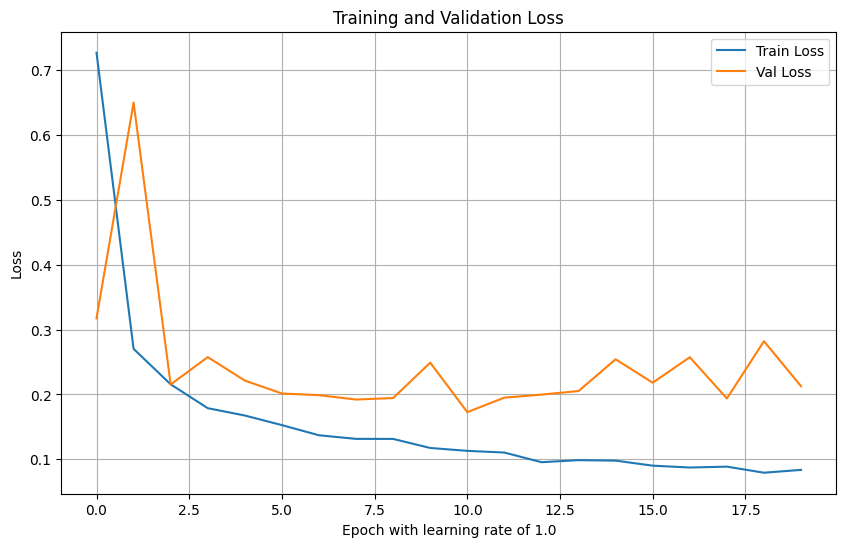

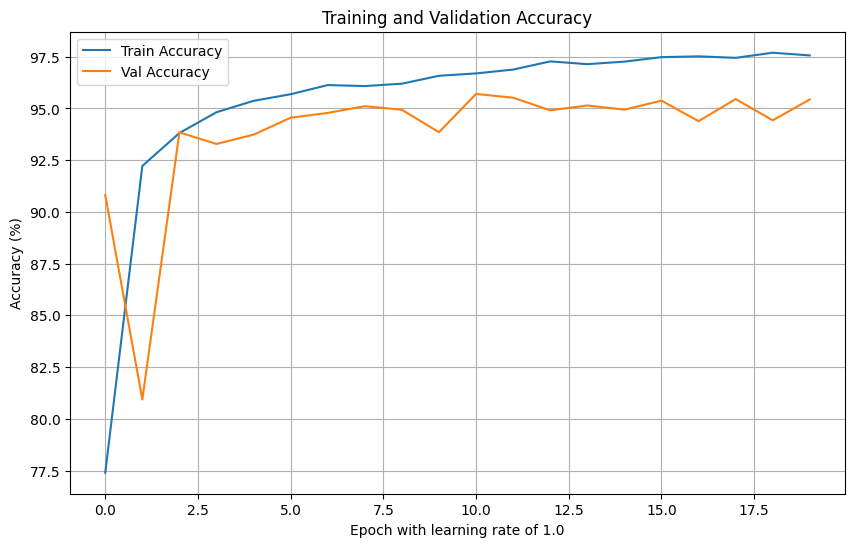

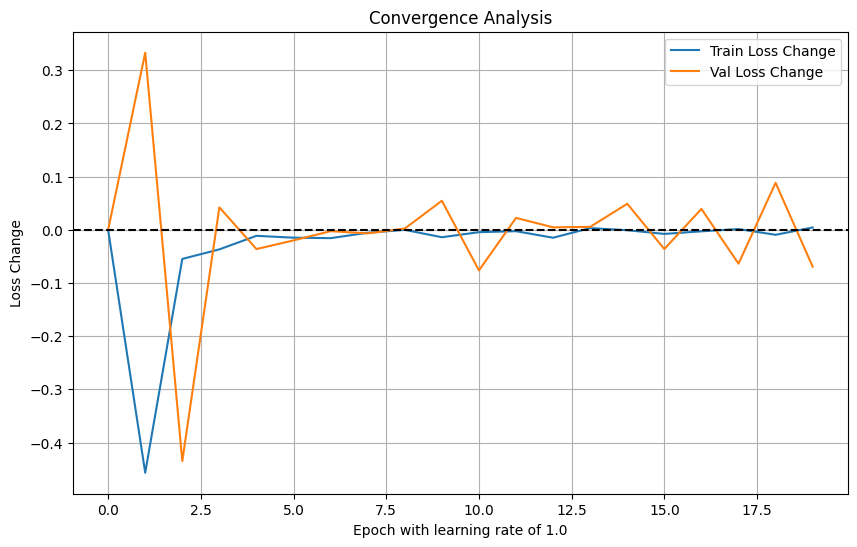


Best learning rate: 0.1 with a validation accuracy of 97.50%
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.4630 | Train Acc: 86.13%
  Val Loss: 0.2811 | Val Acc: 91.62%
Epoch 2/20
  Train Loss: 0.2069 | Train Acc: 93.87%
  Val Loss: 0.1854 |

In [25]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
best_val_accuracy = 0
best_learning_rate = None

for learning_rate in learning_rates:
    parameter_setter(learning_rate=learning_rate)
    train_model()

    max_val_acc = max(val_accs)
    if max_val_acc > best_val_accuracy:
        best_val_accuracy = max_val_acc
        best_learning_rate = learning_rate

    plot_loss(f"with learning rate of {learning_rate}")
    plot_acc(f"with learning rate of {learning_rate}")
    plot_converge(f"with learning rate of {learning_rate}")



### getting accuracy of predications using the best learing rate

In [27]:
print(f"\nBest learning rate: {best_learning_rate} with a validation accuracy of {best_val_accuracy:.2f}%")

parameter_setter(learning_rate=best_learning_rate)
train_model()
predict_test()


Best learning rate: 0.1 with a validation accuracy of 96.54%
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.4807 | Train Acc: 85.76%
  Val Loss: 0.3067 | Val Acc: 90.38%
Epoch 2/20
  Train Loss: 0.2252 | Train Acc: 93.28%
  Val Loss: 0.2009 |

### Comparsion between the different learning rates

*   **Learning Rate 0.001:** Slow convergence, stable loss and accuracy curves.
*   **Learning Rate 0.01:** Faster convergence than 0.001, stable loss and accuracy curves. Good balance.
*   **Learning Rate 0.1:** Fast convergence, more change difference in loss and accuracy. Less stable.
*   **Learning Rate 1.0:** Very fast initial convergence, highly unstable loss and accuracy with significant oscillations. Too high.

Learning rate 0.01 appears to be the most suitable.

### batch size

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.5905 | Train Acc: 83.74%
  Val Loss: 0.3330 | Val Acc: 90.41%
Epoch 2/20
  Train Loss: 0.2927 | Train Acc: 91.57%
  Val Loss: 0.2645 | Val Acc: 92.25%
Epoch 3/20
  Train Loss: 0.2367 | Train Acc: 

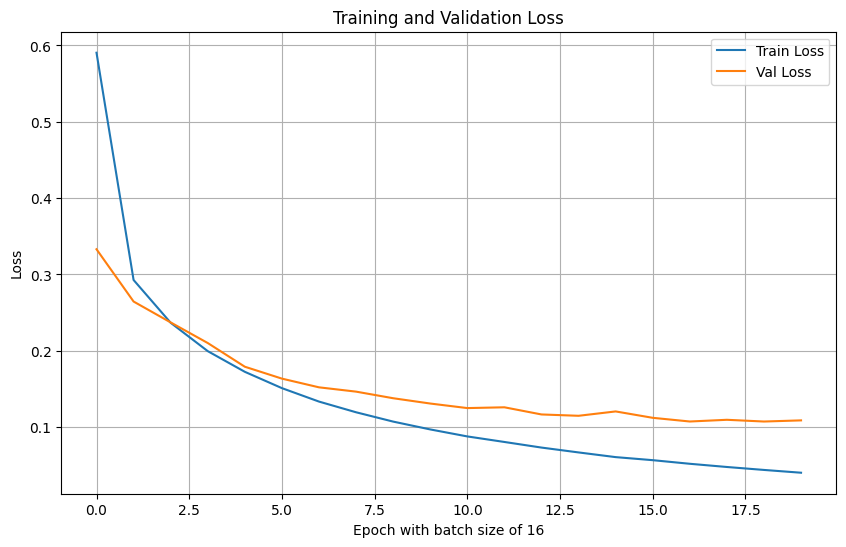

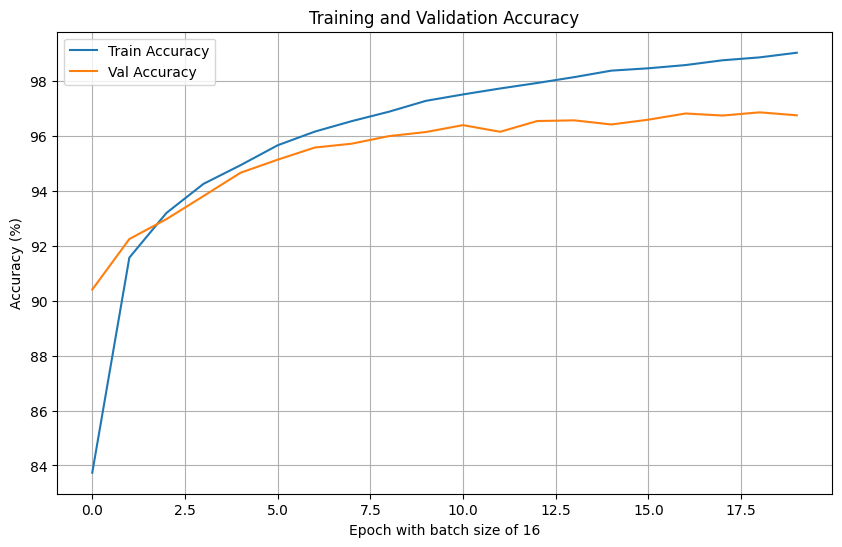

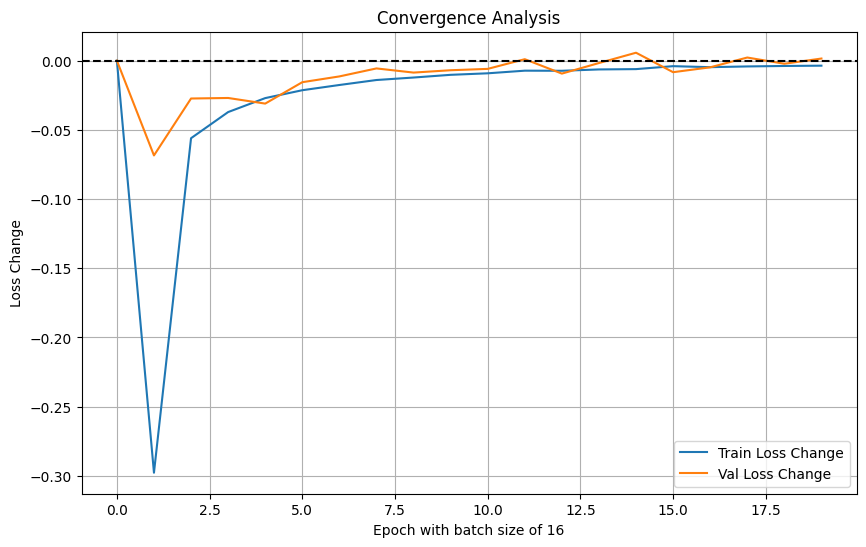

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.8592 | Train Acc: 76.79%
  Val Loss: 0.4152 | Val Acc: 87.67%
Epoch 2/20
  Train Loss: 0.3609 | Train Acc: 89.64%
  Val Loss: 0.3280 | Val Acc: 90.17%
Epoch 3/20
  Train Loss: 0.3038 | Train Acc: 

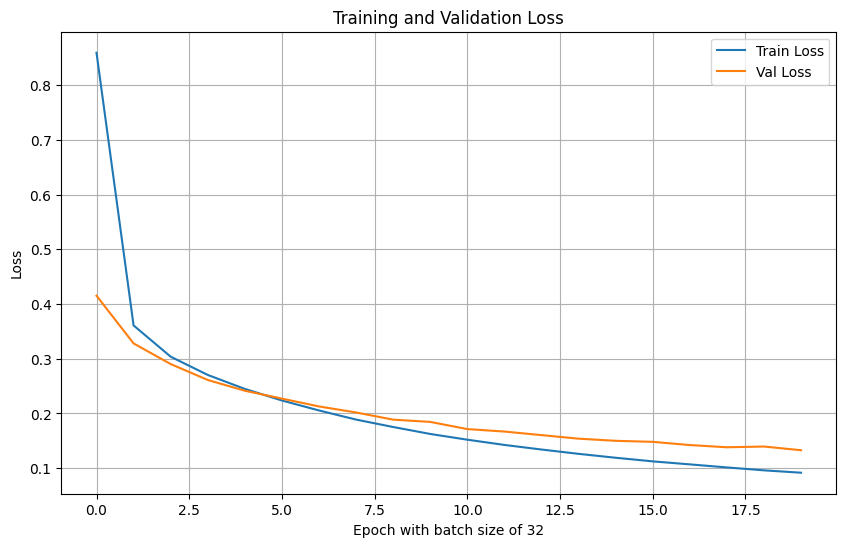

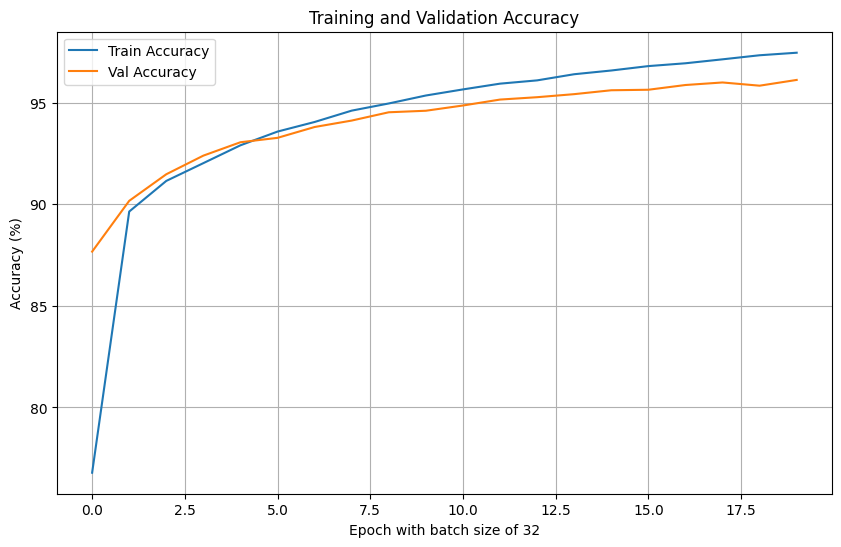

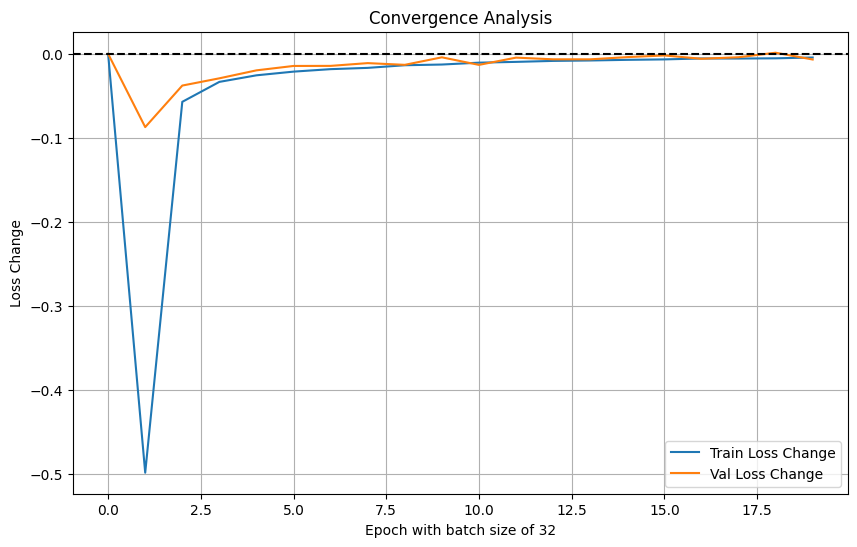

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 1.1948 | Train Acc: 68.20%
  Val Loss: 0.5607 | Val Acc: 85.26%
Epoch 2/20
  Train Loss: 0.4499 | Train Acc: 87.66%
  Val Loss: 0.4018 | Val Acc: 88.62%
Epoch 3/20
  Train Loss: 0.3603 | Train Acc: 

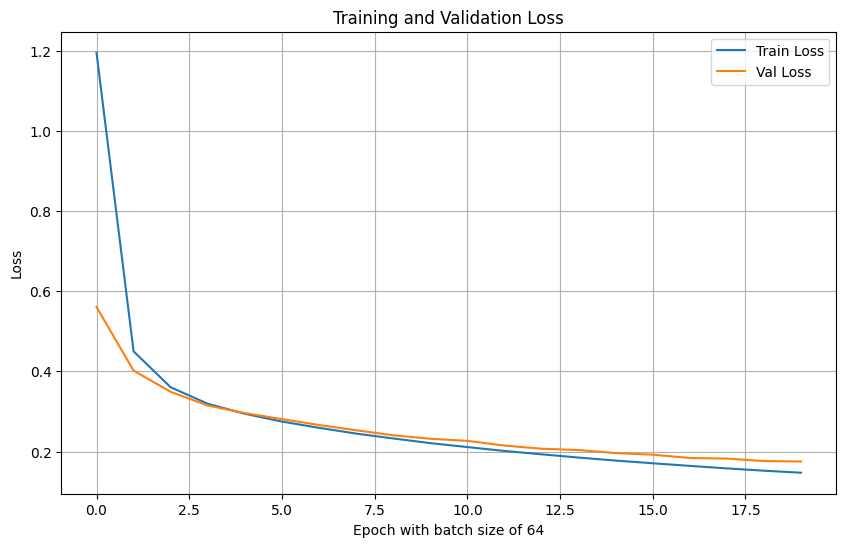

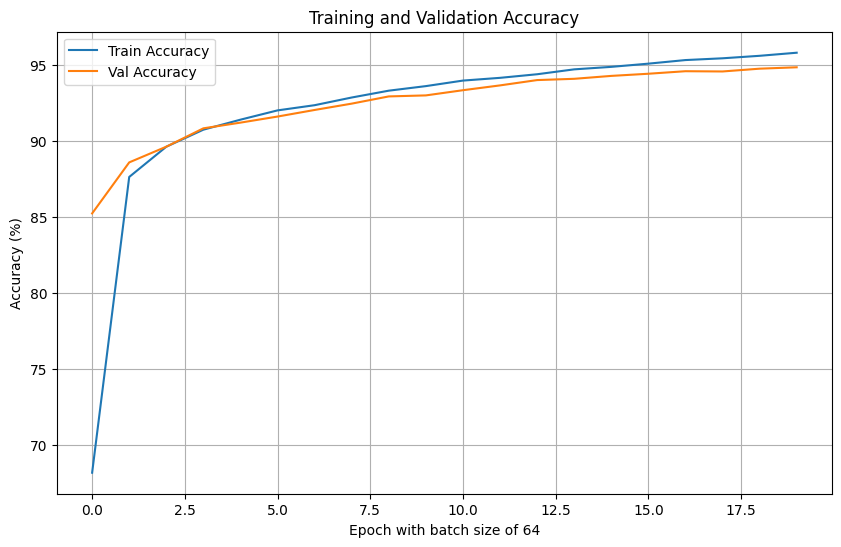

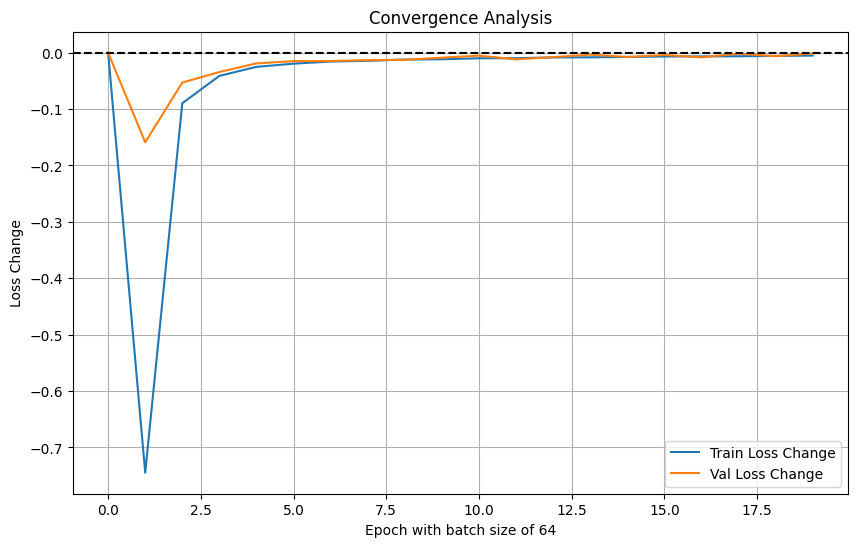

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 1.4614 | Train Acc: 59.52%
  Val Loss: 0.8930 | Val Acc: 77.70%
Epoch 2/20
  Train Loss: 0.6975 | Train Acc: 81.94%
  Val Loss: 0.5703 | Val Acc: 84.35%
Epoch 3/20
  Train Loss: 0.5052 | Train Acc: 

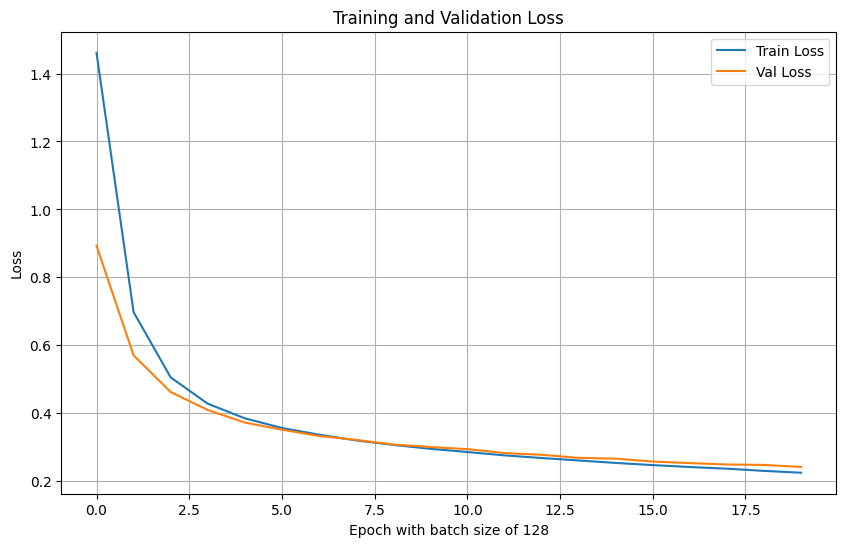

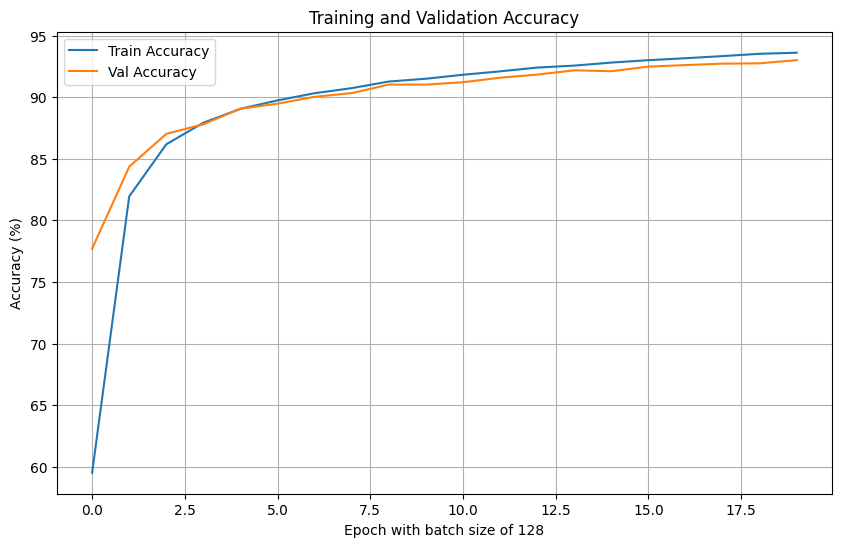

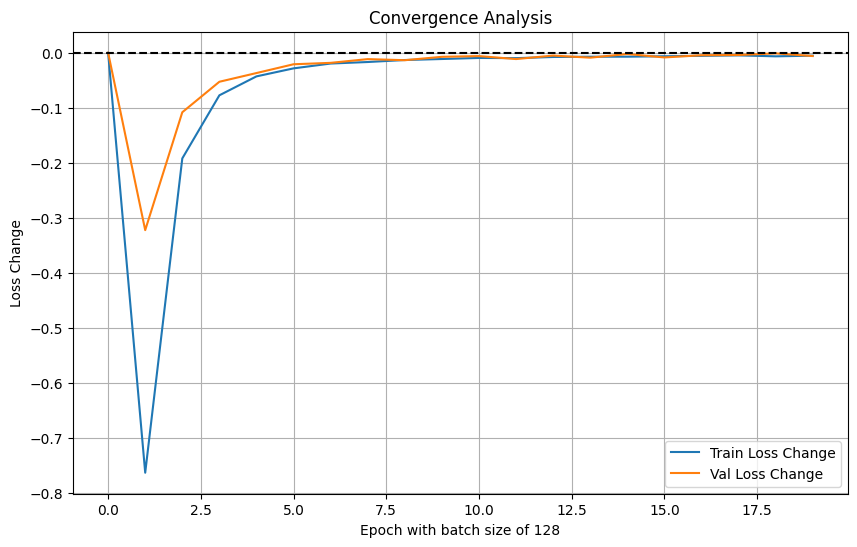


Best batch size: 16 with a validation accuracy of 96.87%


In [30]:
import time

batch_sizes = [16,32,64,128]
best_val_accuracy = 0
best_batch_size = None
training_times = []

for batch_size in batch_sizes:
    parameter_setter(batch_size=batch_size)
    start_time = time.time()
    train_model()
    end_time = time.time()
    training_times.append(end_time - start_time)

    max_val_acc = max(val_accs)
    if max_val_acc > best_val_accuracy:
        best_val_accuracy = max_val_acc
        best_batch_size = batch_size

    plot_loss(f"with batch size of {batch_size}")
    plot_acc(f"with batch size of {batch_size}")
    plot_converge(f"with batch size of {batch_size}")

print(f"\nBest batch size: {best_batch_size} with a validation accuracy of {best_val_accuracy:.2f}%")


### getting accuracy of predications based on the best batch size

In [31]:
print(f"\nBest batch size: {best_batch_size} with a validation accuracy of {best_val_accuracy:.2f}%")

parameter_setter(batch_size=best_batch_size)
train_model()
predict_test()


Best batch size: 16 with a validation accuracy of 96.87%
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 0.6100 | Train Acc: 82.87%
  Val Loss: 0.3300 | Val Acc: 90.27%
Epoch 2/20
  Train Loss: 0.2950 | Train Acc: 91.47%
  Val Loss: 0.2789 | Val

### ploting the time for training speed

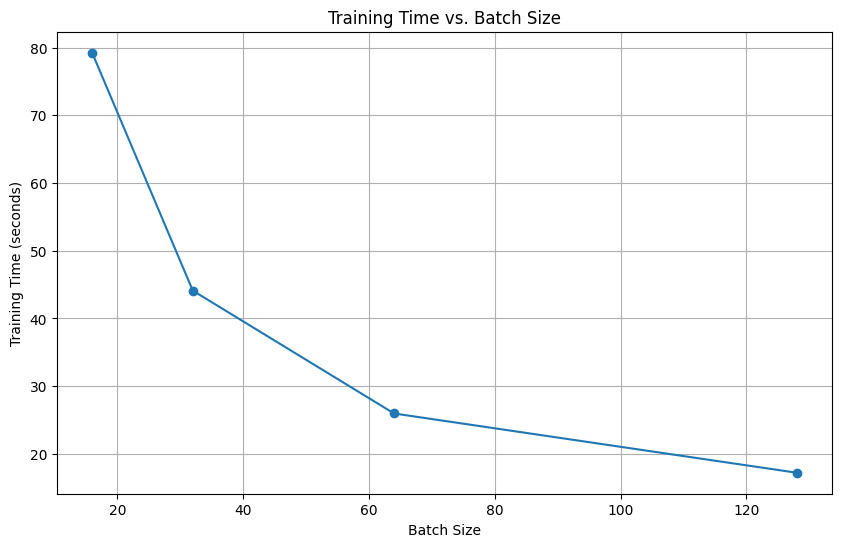

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, training_times, marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time vs. Batch Size')
plt.grid(True)
plt.show()



*   **Smaller Batch Sizes (e.g., 16, 32):** has slower time for each epoch but has faster time for each gradient calc
*   **Larger Batch Sizes (e.g., 64, 128):** has faster time for each epoch but has slower time for each gradient calc

Small batches often provide noise that helps generalization (reaches better validation accuracy). -> has more gradient noise

Large batches can converge quickly in terms of loss but sometimes to worse generalization -> has less gradient noise

# Trying different architectures for the neual network

In [39]:
def create_nn_model(num_hidden_layers, neurons_per_layer):
    layers = []
    layers.append(nn.Linear(28 * 28, neurons_per_layer))

    for _ in range(num_hidden_layers):
        layers.append(nn.ReLU())
        layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))

    layers.append(nn.ReLU())
    layers.append(nn.Linear(neurons_per_layer, 10))

    return nn.Sequential(*layers)

## Define hyperparameter setter for architecture




In [40]:
def parameter_setter(learning_rate=.01, num_epochs=20, batch_size=64, num_hidden_layers=2, neurons_per_layer=128):
    global loss_function, optimizer, loader, neural_network, device
    neural_network = create_nn_model(num_hidden_layers, neurons_per_layer)

    for layer in neural_network:
        if isinstance(layer, nn.Linear):
            init.kaiming_uniform_(layer.weight, nonlinearity='relu')
            if layer.bias is not None:
                init.zeros_(layer.bias)


    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    neural_network.to(device)

    loss_function = nn.CrossEntropyLoss()
    optimizer = SGD.SGD(neural_network.parameters(), lr=learning_rate)
    loader=dl.build_loader(batch_size)


## Storing the result of the different architectures




In [ ]:
import pandas as pd

hidden_layers = [2, 3, 4, 5]
neurons_per_layer_list = [64, 128, 256, 512]

architecture_results = []

for num_hidden_layers in hidden_layers:
    for neurons in neurons_per_layer_list:
        print(f"Training with {num_hidden_layers} hidden layers and {neurons} neurons per layer")
        parameter_setter(num_hidden_layers=num_hidden_layers, neurons_per_layer=neurons)
        train_model()

        architecture_info = {
            'num_hidden_layers': num_hidden_layers,
            'neurons_per_layer': neurons,
            'best_val_accuracy': max(val_accs),
        }
        architecture_results.append(architecture_info)


architecture_data_frame = pd.DataFrame(architecture_results)

print("\n=========Architecture Comparison Table===========\n")
display(architecture_df)

best_architecture = architecture_df.loc[architecture_df['best_val_accuracy'].idxmax()]

print(f"\nBest Architecture:")
print(f"Hidden Layers: {best_architecture['num_hidden_layers']}, Neurons per Layer: {best_architecture['neurons_per_layer']}, Best Val Accuracy: {best_architecture['best_val_accuracy']:.2f}%")

Training with 2 hidden layers and 64 neurons per layer
Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/20
  Train Loss: 1.0182 | Train Acc: 69.86%
  Val Loss: 0.4774 | Val Acc: 86.18%
Epoch 2/20
  Train Loss: 0.3912 | Train Acc: 88.75%
  Val Loss: 0.3587 | Val Ac

In [ ]:
###getting the Accuracy of predication based on the best architecture

In [ ]:

parameter_setter(
    num_hidden_layers=int(best_architecture['num_hidden_layers']),
    neurons_per_layer=int(best_architecture['neurons_per_layer'])
)
train_model()
predict_test()